In [1]:

import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'

matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [2]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [3]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/combined_noneffector.fasta')
#33374 - 27977 =5397
#non-effector = 5397

In [4]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/IDR_arabi_effector_domain_cut.tsv', skip_bad=True, safe=False)

In [6]:
HP.domains[4]

|Domain: IDR_1 (1-74, len=74) in protein HopX1b

In [7]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 30
UPPER = 80
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 1591 IDRs; this will be 2531281 epsilon calculations


In [8]:
mode = 'mpipi'

In [9]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)



  0%|          | 0/1591 [00:00<?, ?it/s]

In [10]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [11]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 15.49%
Percentage of pairs that are repulsive: 84.51%


In [14]:
import pandas as pd

In [12]:
#all_cross_interactions
all_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [15]:
eff_df = pd.read_csv('/home/wenyuantong/Desktop/data/IDR_psytec_domain.tsv',  sep='\t', header=None)
display(eff_df.head())

,0,1,2,3
0,HopX1a,1,88,N-terminal
1,HopX1a,200,247,Middle
2,HopX1a,298,380,C-terminal
3,HopX1c,1,87,N-terminal
4,HopX1c,212,267,Middle


In [16]:
eff_df[0] = eff_df[0].str.replace(' ', '')
substrings_to_find = eff_df[0].tolist()
display(substrings_to_find[:10])

['HopX1a',
 'HopX1a',
 'HopX1a',
 'HopX1c',
 'HopX1c',
 'HopX1b',
 'HopX1b',
 'HopX1i',
 'HopX1i',
 'HopX1e']

In [18]:
#all_atr_interactions
atr_df = pd.DataFrame(all_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(atr_df)

,IDR1,IDR2,E_value
0,HopX1a_IDR_1_1_80,HopX1a_IDR_1_1_80,3.790395
1,HopX1a_IDR_1_1_80,HopX1a_IDR_1_298_377,3.844718
2,HopX1a_IDR_1_1_80,HopX1c_IDR_1_1_80,3.180637
3,HopX1a_IDR_1_1_80,HopX1c_IDR_1_212_267,1.629701
4,HopX1a_IDR_1_1_80,HopX1b_IDR_1_1_74,3.486738
...,...,...,...
2531276,P82658_IDR_1_1_60,Q9LSU8_IDR_1_135_179,2.672961
2531277,P82658_IDR_1_1_60,Q9FHZ8_IDR_1_1_48,1.793592
2531278,P82658_IDR_1_1_60,F4JJ52_IDR_1_388_467,2.421614
2531279,P82658_IDR_1_1_60,F4JJ52_IDR_2_468_526,2.628966


In [19]:
# Combine the substrings into a single regex pattern using '|' (OR operator)
# This pattern will match if any of the substrings are found.
search_pattern = '|'.join(substrings_to_find)

# Filter the original DataFrame
# The `case=False` argument makes the search case-insensitive
# The `na=False` argument treats NaN values as not containing the substring
sub_df_multi = atr_df[atr_df['IDR1'].str.contains(search_pattern, case=False, na=False)]

#print(f"\nSub-DataFrame containing any of the terms: {substrings_to_find} in 'item_description' column:")
display(sub_df_multi)

,IDR1,IDR2,E_value
0,HopX1a_IDR_1_1_80,HopX1a_IDR_1_1_80,3.790395
1,HopX1a_IDR_1_1_80,HopX1a_IDR_1_298_377,3.844718
2,HopX1a_IDR_1_1_80,HopX1c_IDR_1_1_80,3.180637
3,HopX1a_IDR_1_1_80,HopX1c_IDR_1_212_267,1.629701
4,HopX1a_IDR_1_1_80,HopX1b_IDR_1_1_74,3.486738
...,...,...,...
1113695,AvrB1b_IDR_1_1_31,Q9LSU8_IDR_1_135_179,0.920216
1113696,AvrB1b_IDR_1_1_31,Q9FHZ8_IDR_1_1_48,0.529246
1113697,AvrB1b_IDR_1_1_31,F4JJ52_IDR_1_388_467,1.155937
1113698,AvrB1b_IDR_1_1_31,F4JJ52_IDR_2_468_526,1.044006


In [20]:
sub_df_not_containing = sub_df_multi[~sub_df_multi['IDR2'].str.contains(search_pattern, case=False, na=False)]

#print(f"\nSub-DataFrame containing rows that *do not* contain any of the terms in '{search_pattern}' in 'item_description' column:")
display(sub_df_not_containing)

,IDR1,IDR2,E_value
700,HopX1a_IDR_1_1_80,Q9FGQ9_IDR_1_1_80,0.085635
701,HopX1a_IDR_1_1_80,Q9ZV43_IDR_1_1_80,4.455041
702,HopX1a_IDR_1_1_80,Q9ZV43_IDR_2_81_160,4.915681
703,HopX1a_IDR_1_1_80,Q9ZV43_IDR_3_161_240,2.562795
704,HopX1a_IDR_1_1_80,Q9ZV43_IDR_4_241_320,4.756326
...,...,...,...
1113695,AvrB1b_IDR_1_1_31,Q9LSU8_IDR_1_135_179,0.920216
1113696,AvrB1b_IDR_1_1_31,Q9FHZ8_IDR_1_1_48,0.529246
1113697,AvrB1b_IDR_1_1_31,F4JJ52_IDR_1_388_467,1.155937
1113698,AvrB1b_IDR_1_1_31,F4JJ52_IDR_2_468_526,1.044006


In [25]:
output_file_path = '/home/wenyuantong/Desktop/data/500_arabi_effector_cross.csv'
sub_df_not_containing.to_csv(output_file_path, header=False, index=False)

In [30]:
#'/home/wenyuantong/Desktop/data/500_arabi_noneffector_cross.csv'
noneff_df = pd.read_csv('/home/wenyuantong/Desktop/data/500_arabi_noneffector_cross.csv')
display(noneff_df.head())

,IDR1,IDR2,E_value
0,Q87VW8_IDR_1_1_55,Q9FGQ9_IDR_1_1_80,0.405055
1,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_1_1_80,2.353809
2,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_2_81_160,3.472236
3,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_3_161_240,2.242515
4,Q87VW8_IDR_1_1_55,Q9ZV43_IDR_4_241_320,3.577676


In [32]:
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

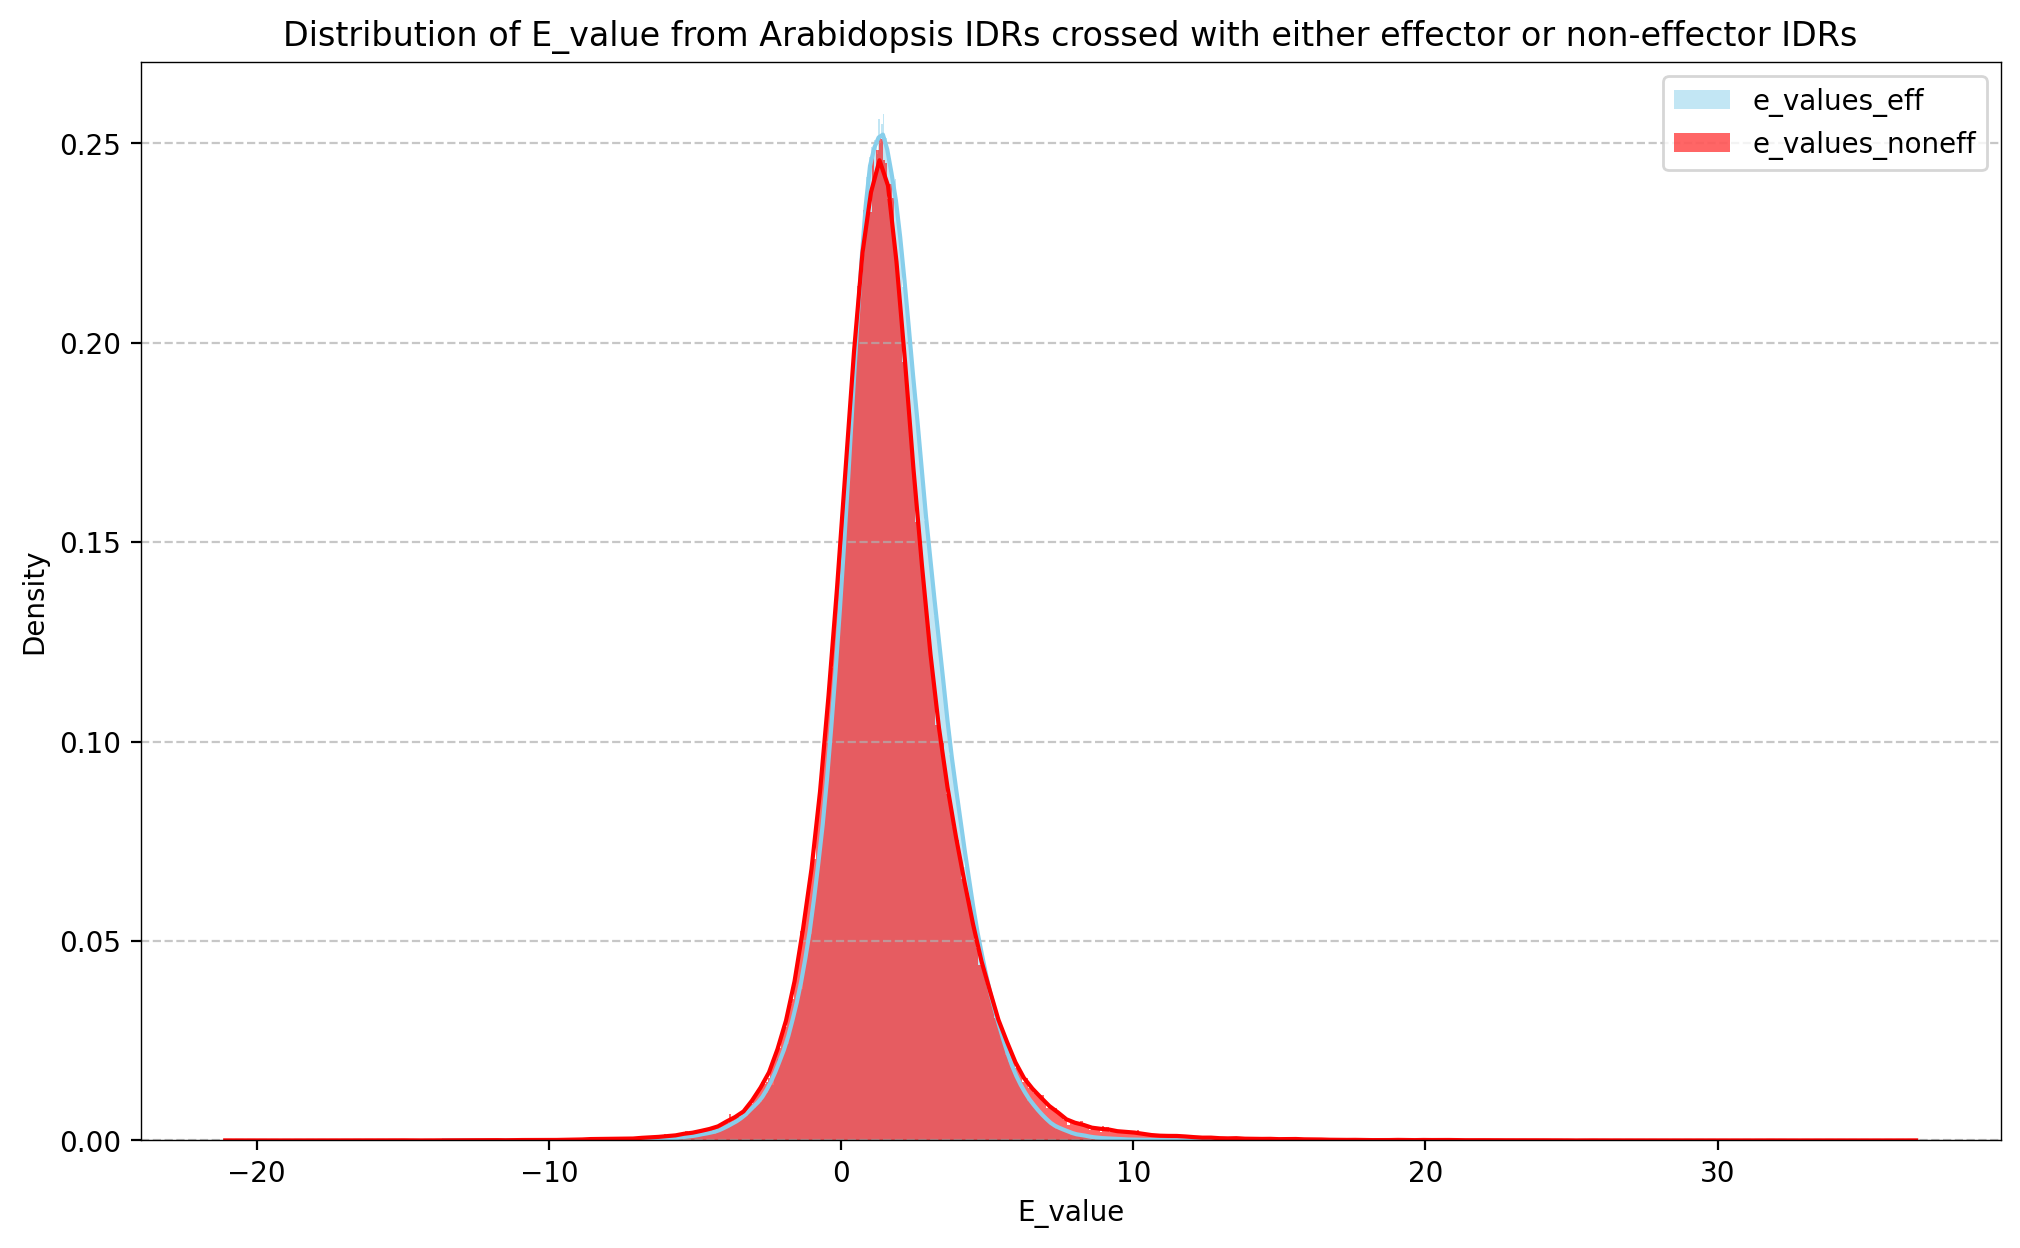

/tmp/ipykernel_180603/2321893540.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='DataFrame', y='E_value', data=melted_df, inner='quartile', palette='coolwarm')


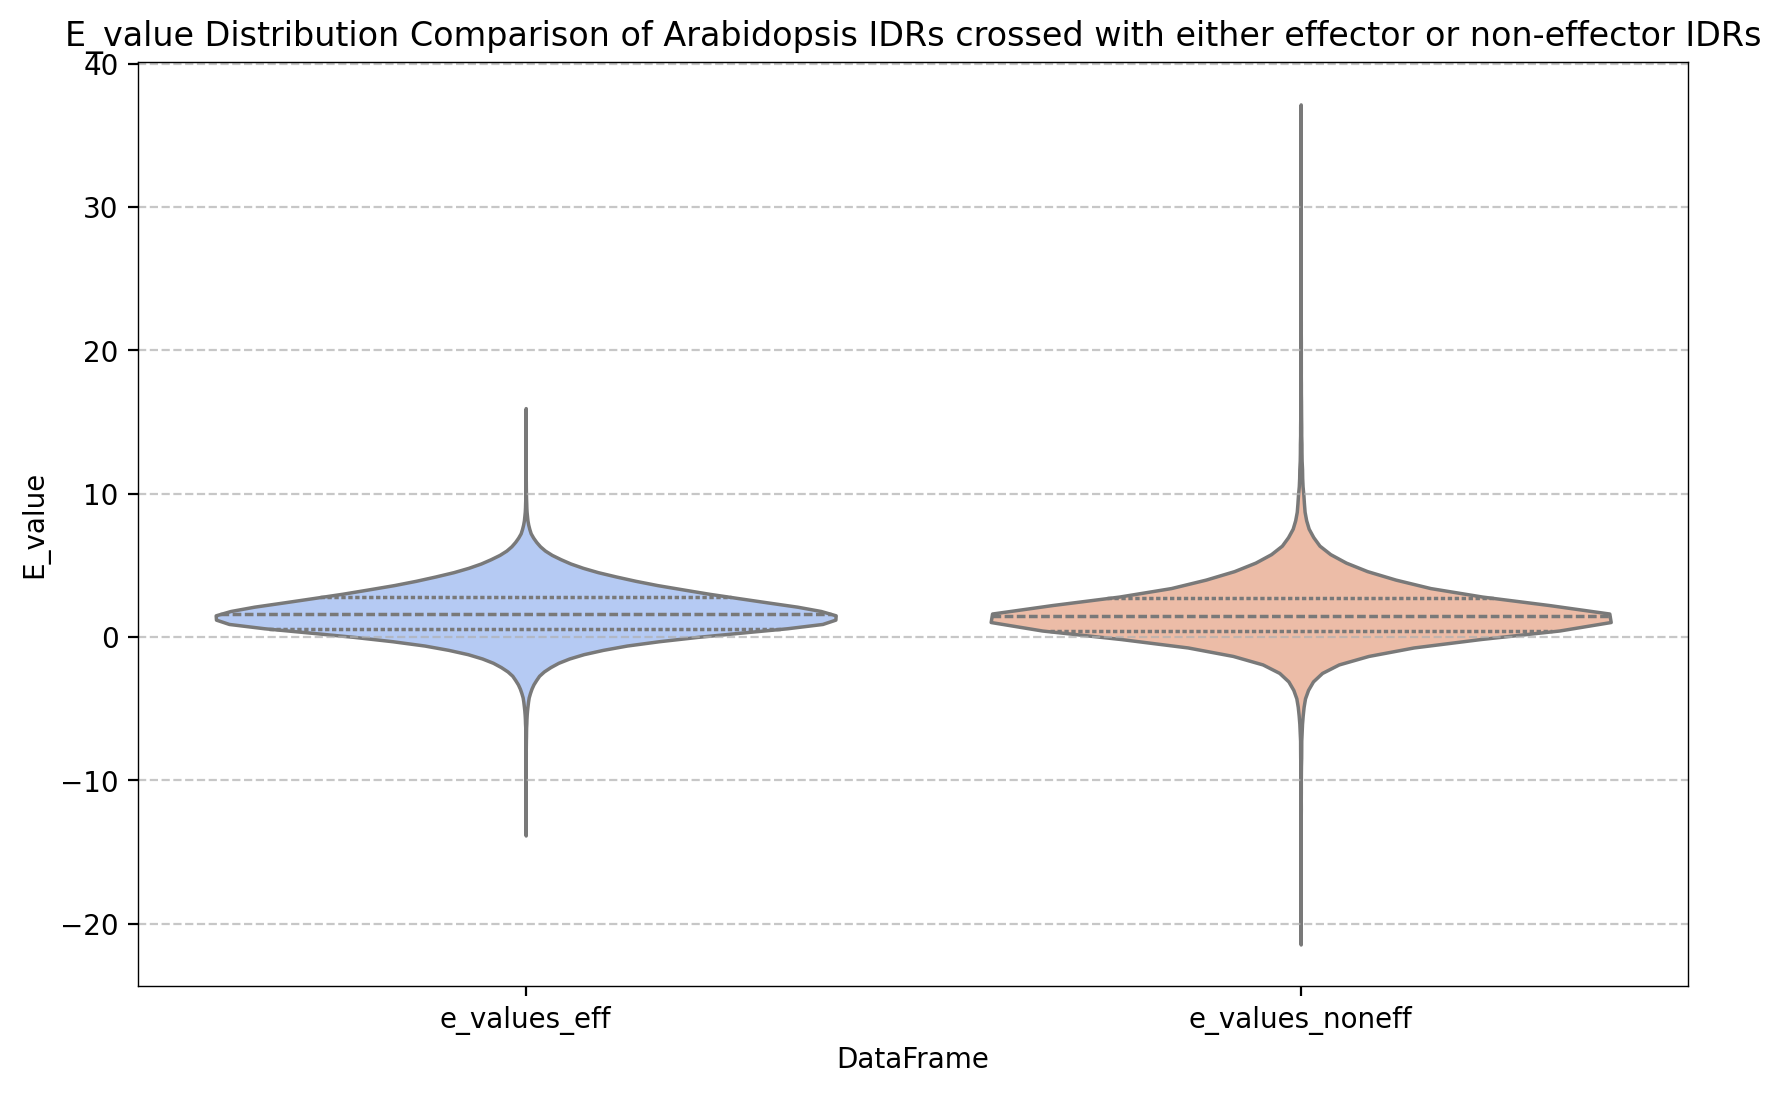

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

try:
    # Assuming 'E_value' is a numeric column and exists in both dataframes.
    # If these columns don't exist, a KeyError will be caught.
    e_values_eff = sub_df_not_containing['E_value'].copy()
    e_values_noneff = noneff_df['E_value'].copy()

    # Create a DataFrame for plotting both distributions
    plot_df = pd.DataFrame({
        'e_values_eff': e_values_eff,
        'e_values_noneff': e_values_noneff 
    })

    # --- Plotting Option 1: Overlapping Histograms for distribution comparison ---
    plt.figure(figsize=(12, 7))
    sns.histplot(plot_df['e_values_eff'], color="skyblue", label="e_values_eff", kde=True, stat="density", linewidth=0)
    sns.histplot(plot_df['e_values_noneff'], color="red", label="e_values_noneff", kde=True, stat="density", linewidth=0, alpha=0.6)
    plt.title('Distribution of E_value from Arabidopsis IDRs crossed with either effector or non-effector IDRs')
    plt.xlabel('E_value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plotting Option 2: Violin plot for distribution comparison ---
    # Melt the dataframe for seaborn's violinplot to compare distributions side-by-side
    melted_df = plot_df.melt(var_name='DataFrame', value_name='E_value')
    
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='DataFrame', y='E_value', data=melted_df, inner='quartile', palette='coolwarm')
    plt.title('E_value Distribution Comparison of Arabidopsis IDRs crossed with either effector or non-effector IDRs')
    plt.xlabel('DataFrame')
    plt.ylabel('E_value')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except KeyError:
    print("Error: The 'E_value' column was not found in one or both of the DataFrames (df_rin4 or df_processed).")
    print("Please ensure the column exists or clarify which of the existing columns you would like to plot as 'E_value'.")
    print(f"Columns in df_rin4 are: {df_rin4.columns.tolist()}")
    print(f"Columns in df_processed are: {df_processed.columns.tolist()}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")